In [42]:
import pandas as pd

In [43]:
df_prod = pd.read_excel(r'data/data_prod_vs_demand.xlsx', sheet_name='PRODUCTION')
df_demand = pd.read_excel(r'data/data_prod_vs_demand.xlsx', sheet_name='DEMAND')

In [44]:
# Aggregare df_demand per scenario, country, Year and Metal (sum)
df_demand_grouped = df_demand.groupby(['Scenario', 'Country', 'Year', 'Metal'], as_index=False)['Metal_demand_t'].sum()

In [45]:
df_demand_grouped

,Scenario,Country,Year,Metal,Metal_demand_t
0,Canada Net-zero,Canada,2020,Cobalt,1.093070e+03
1,Canada Net-zero,Canada,2020,Copper,7.344569e+05
2,Canada Net-zero,Canada,2020,Neodymium,0.000000e+00
3,Canada Net-zero,Canada,2020,Nickel,6.803369e+03
4,Canada Net-zero,Canada,2021,Cobalt,1.169536e+03
...,...,...,...,...,...
525,Global Net-zero,Canada,2050,Copper,1.929875e+06
526,Global Net-zero,Canada,2050,Graphite,2.113346e+03
527,Global Net-zero,Canada,2050,Lithium,1.122711e+05
528,Global Net-zero,Canada,2050,Neodymium,1.005535e+04


In [46]:
#df_prod.columns = df_prod.columns.str.strip()

In [47]:
df_demand = df_demand[df_demand['Scenario'] != 'Global Net-zero']

In [48]:
# Uniquement garder les années de 2025 à 2040
df_demand = df_demand[df_demand['Year'].between(2025, 2040)]
df_prod = df_prod[df_prod['Year'].between(2025, 2040)]

In [49]:
df_demand

,Scenario,Country,Year,Technology,Metal,Metal_demand_t,Mode,Powertain,Powertrain
12,Canada Net-zero,Canada,2025,Bioenergy,Cobalt,5.387200,NaN,NaN,NaN
13,Canada Net-zero,Canada,2025,Bioenergy,Copper,5986.526000,NaN,NaN,NaN
14,Canada Net-zero,Canada,2025,Bioenergy,Nickel,53.872000,NaN,NaN,NaN
15,Canada Net-zero,Canada,2026,Bioenergy,Cobalt,5.387200,NaN,NaN,NaN
16,Canada Net-zero,Canada,2026,Bioenergy,Copper,5986.526000,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...
12356,Canada Net-zero,Canada,2040,Vehicle motor,Neodymium,0.497845,Trucks,NaN,FCEV
12357,Canada Net-zero,Canada,2040,Vehicle motor,Copper,27857.261249,Cars,NaN,PHEV
12358,Canada Net-zero,Canada,2040,Vehicle motor,Neodymium,1394.417989,Cars,NaN,PHEV
12359,Canada Net-zero,Canada,2040,Vehicle motor,Copper,5629.685090,Vans,NaN,PHEV


In [50]:
def plot_prod_vs_demand_totals_facets_clean(
    df_prod,
    df_demand,
    metals=None,
    prod_scen_col="Scenario",
    demand_scen_col="Scenario",
    year_col="Year",
    demand_value_col="Metal_demand_t",
    prod_value_col="Value_t_refining",
    figsize=(14, 8),
    dpi=350,
    savepath='results/Prod_vs_demand/Prod_vs_demand'
):
    """
    Clean comparison of production vs demand totals, every 5 years (2020–2040).

    Production:
        df_prod[prod_value_col]

    Demand:
        df_demand[demand_value_col]

    The figure uses a 3x2 grid. When there are 5 metals, the
    sixth panel is used to display the legend.
    """

    import numpy as np
    import matplotlib.pyplot as plt
    import seaborn as sns
    from matplotlib.patches import Patch

    # ============================================================
    # Production already in LONG format
    # ============================================================

    prod_long = df_prod.copy()

    prod_long = prod_long.rename(
        columns={"Mineral": "Metal"}
    )

    prod_long["Production_t"] = prod_long[prod_value_col]

    # ============================================================
    # Filter years
    # ============================================================

    prod_long = prod_long[
        prod_long[year_col].between(2020, 2040)
        & (prod_long[year_col] % 5 == 0)
    ]

    df_demand = df_demand[
        df_demand[year_col].between(2020, 2040)
        & (df_demand[year_col] % 5 == 0)
    ]

    # ============================================================
    # Metals
    # ============================================================

    if metals is None:
        metals = sorted(
            df_demand["Metal"].dropna().unique()
        )

    # ============================================================
    # Aggregate demand
    # ============================================================

    df_demand_total = (
        df_demand
        .groupby(
            [demand_scen_col, year_col, "Metal"]
        )[demand_value_col]
        .sum()
        .reset_index()
    )

    # ============================================================
    # Colors
    # ============================================================

    prod_scenarios = sorted(
        prod_long[prod_scen_col].unique()
    )

    demand_scenarios = sorted(
        df_demand_total[demand_scen_col].unique()
    )

    prod_colors = sns.color_palette(
        "Greens",
        len(prod_scenarios)
    )

    demand_colors = sns.color_palette(
        "Reds",
        len(demand_scenarios)
    )

    color_map = dict(
        zip(
            prod_scenarios + demand_scenarios,
            prod_colors + demand_colors
        )
    )

    # ============================================================
    # Figure setup
    # ============================================================

    n_metals = len(metals)

    ncols = 3
    nrows = int(np.ceil(n_metals / ncols))

    # Make sure there is an additional panel for the legend
    if n_metals % ncols != 0:
        nrows = int(np.ceil((n_metals + 1) / ncols))

    fig, axes = plt.subplots(
        nrows=nrows,
        ncols=ncols,
        figsize=figsize,
        dpi=dpi
    )

    # Make axes iterable even if there is only one subplot
    axes = np.atleast_1d(axes).flatten()

    # ============================================================
    # Bar parameters
    # ============================================================

    bar_width = 0.15
    group_offset = 0.2

    # ============================================================
    # Plot each metal
    # ============================================================

    for i, metal in enumerate(metals):

        ax = axes[i]

        d_prod = prod_long[
            prod_long["Metal"] == metal
        ]

        d_demand = df_demand_total[
            df_demand_total["Metal"] == metal
        ]

        # --------------------------------------------------------
        # Empty metal
        # --------------------------------------------------------

        if d_prod.empty and d_demand.empty:
            ax.set_visible(False)
            continue

        # --------------------------------------------------------
        # Years
        # --------------------------------------------------------

        all_years = sorted(
            set(d_prod[year_col])
            | set(d_demand[year_col])
        )

        x = np.arange(len(all_years))

        # --------------------------------------------------------
        # Production bars
        # --------------------------------------------------------

        for j, scen in enumerate(prod_scenarios):

            sub = (
                d_prod[
                    d_prod[prod_scen_col] == scen
                ]
                .set_index(year_col)
                .reindex(all_years)
                .fillna(0)
            )

            ax.bar(
                x - group_offset + j * bar_width,
                sub["Production_t"],
                width=bar_width,
                color=color_map[scen],
                label=f"Prod – {scen}" if i == 0 else "",
                alpha=0.9,
            )

        # --------------------------------------------------------
        # Demand bars
        # --------------------------------------------------------

        for j, scen in enumerate(demand_scenarios):

            sub = (
                d_demand[
                    d_demand[demand_scen_col] == scen
                ]
                .set_index(year_col)
                .reindex(all_years)
                .fillna(0)
            )

            ax.bar(
                x + group_offset + j * bar_width,
                sub[demand_value_col],
                width=bar_width,
                color=color_map[scen],
                label=f"Demand – {scen}" if i == 0 else "",
                alpha=0.9,
            )

        # --------------------------------------------------------
        # Axis formatting
        # --------------------------------------------------------

        ax.set_xticks(x)

        ax.set_xticklabels(
            all_years,
            fontsize=10
        )

        ax.set_title(
            metal,
            fontsize=14,
            fontweight="bold"
        )

        ax.tick_params(
            axis="y",
            labelsize=8
        )

        ax.grid(False)

        # Y label only on left column
        if i % ncols == 0:
            ax.set_ylabel(
                "tonnes",
                fontsize=12
            )
        else:
            ax.set_ylabel("")

    # ============================================================
# Legend panel
# ============================================================

    legend_index = n_metals

    if legend_index < len(axes):

        legend_ax = axes[legend_index]

        # Remove axes
        legend_ax.axis("off")

        # Legend handles
        handles = [
            Patch(
                color=color_map[s],
                label=s
            )
            for s in (
                prod_scenarios
                + demand_scenarios
            )
        ]

        # --------------------------------------------------------
        # Small, non-bold title
        # --------------------------------------------------------

        legend_ax.text(
            0.5,
            0.8,
            "",
            ha="center",
            va="center",
            fontsize=13,
            fontweight="normal",
            transform=legend_ax.transAxes
        )

        # --------------------------------------------------------
        # Legend
        # --------------------------------------------------------

        legend = legend_ax.legend(
            handles=handles,
            loc="center",
            bbox_to_anchor=(0.5, 0.45),
            ncol=1,
            fontsize=14,
            frameon=True,
            fancybox=False,
            framealpha=1,
            edgecolor="0.75",
            facecolor="white",
            borderpad=1.0,
            labelspacing=1.0,
            handlelength=1.6,
            handletextpad=0.8,
        )

        # Make sure the legend itself has no title
        legend.set_title(None)
    # ============================================================
    # Hide any remaining unused axes
    # ============================================================

    for j in range(n_metals + 1, len(axes)):
        axes[j].set_visible(False)

    # ============================================================
    # Layout
    # ============================================================

    fig.tight_layout()

    # ============================================================
    # Save
    # ============================================================

    if savepath:

        fig.savefig(
            f"{savepath}.png",
            bbox_inches="tight"
        )

        fig.savefig(
            f"{savepath}.svg",
            bbox_inches="tight"
        )

        fig.savefig(
            f"{savepath}.pdf",
            bbox_inches="tight"
        )

        print(
            f"Saved to {savepath}.png, "
            f"{savepath}.svg and {savepath}.pdf"
        )

    plt.show()

Saved to results/Prod_vs_demand/Prod_vs_demand_selected_metals.png, results/Prod_vs_demand/Prod_vs_demand_selected_metals.svg and results/Prod_vs_demand/Prod_vs_demand_selected_metals.pdf


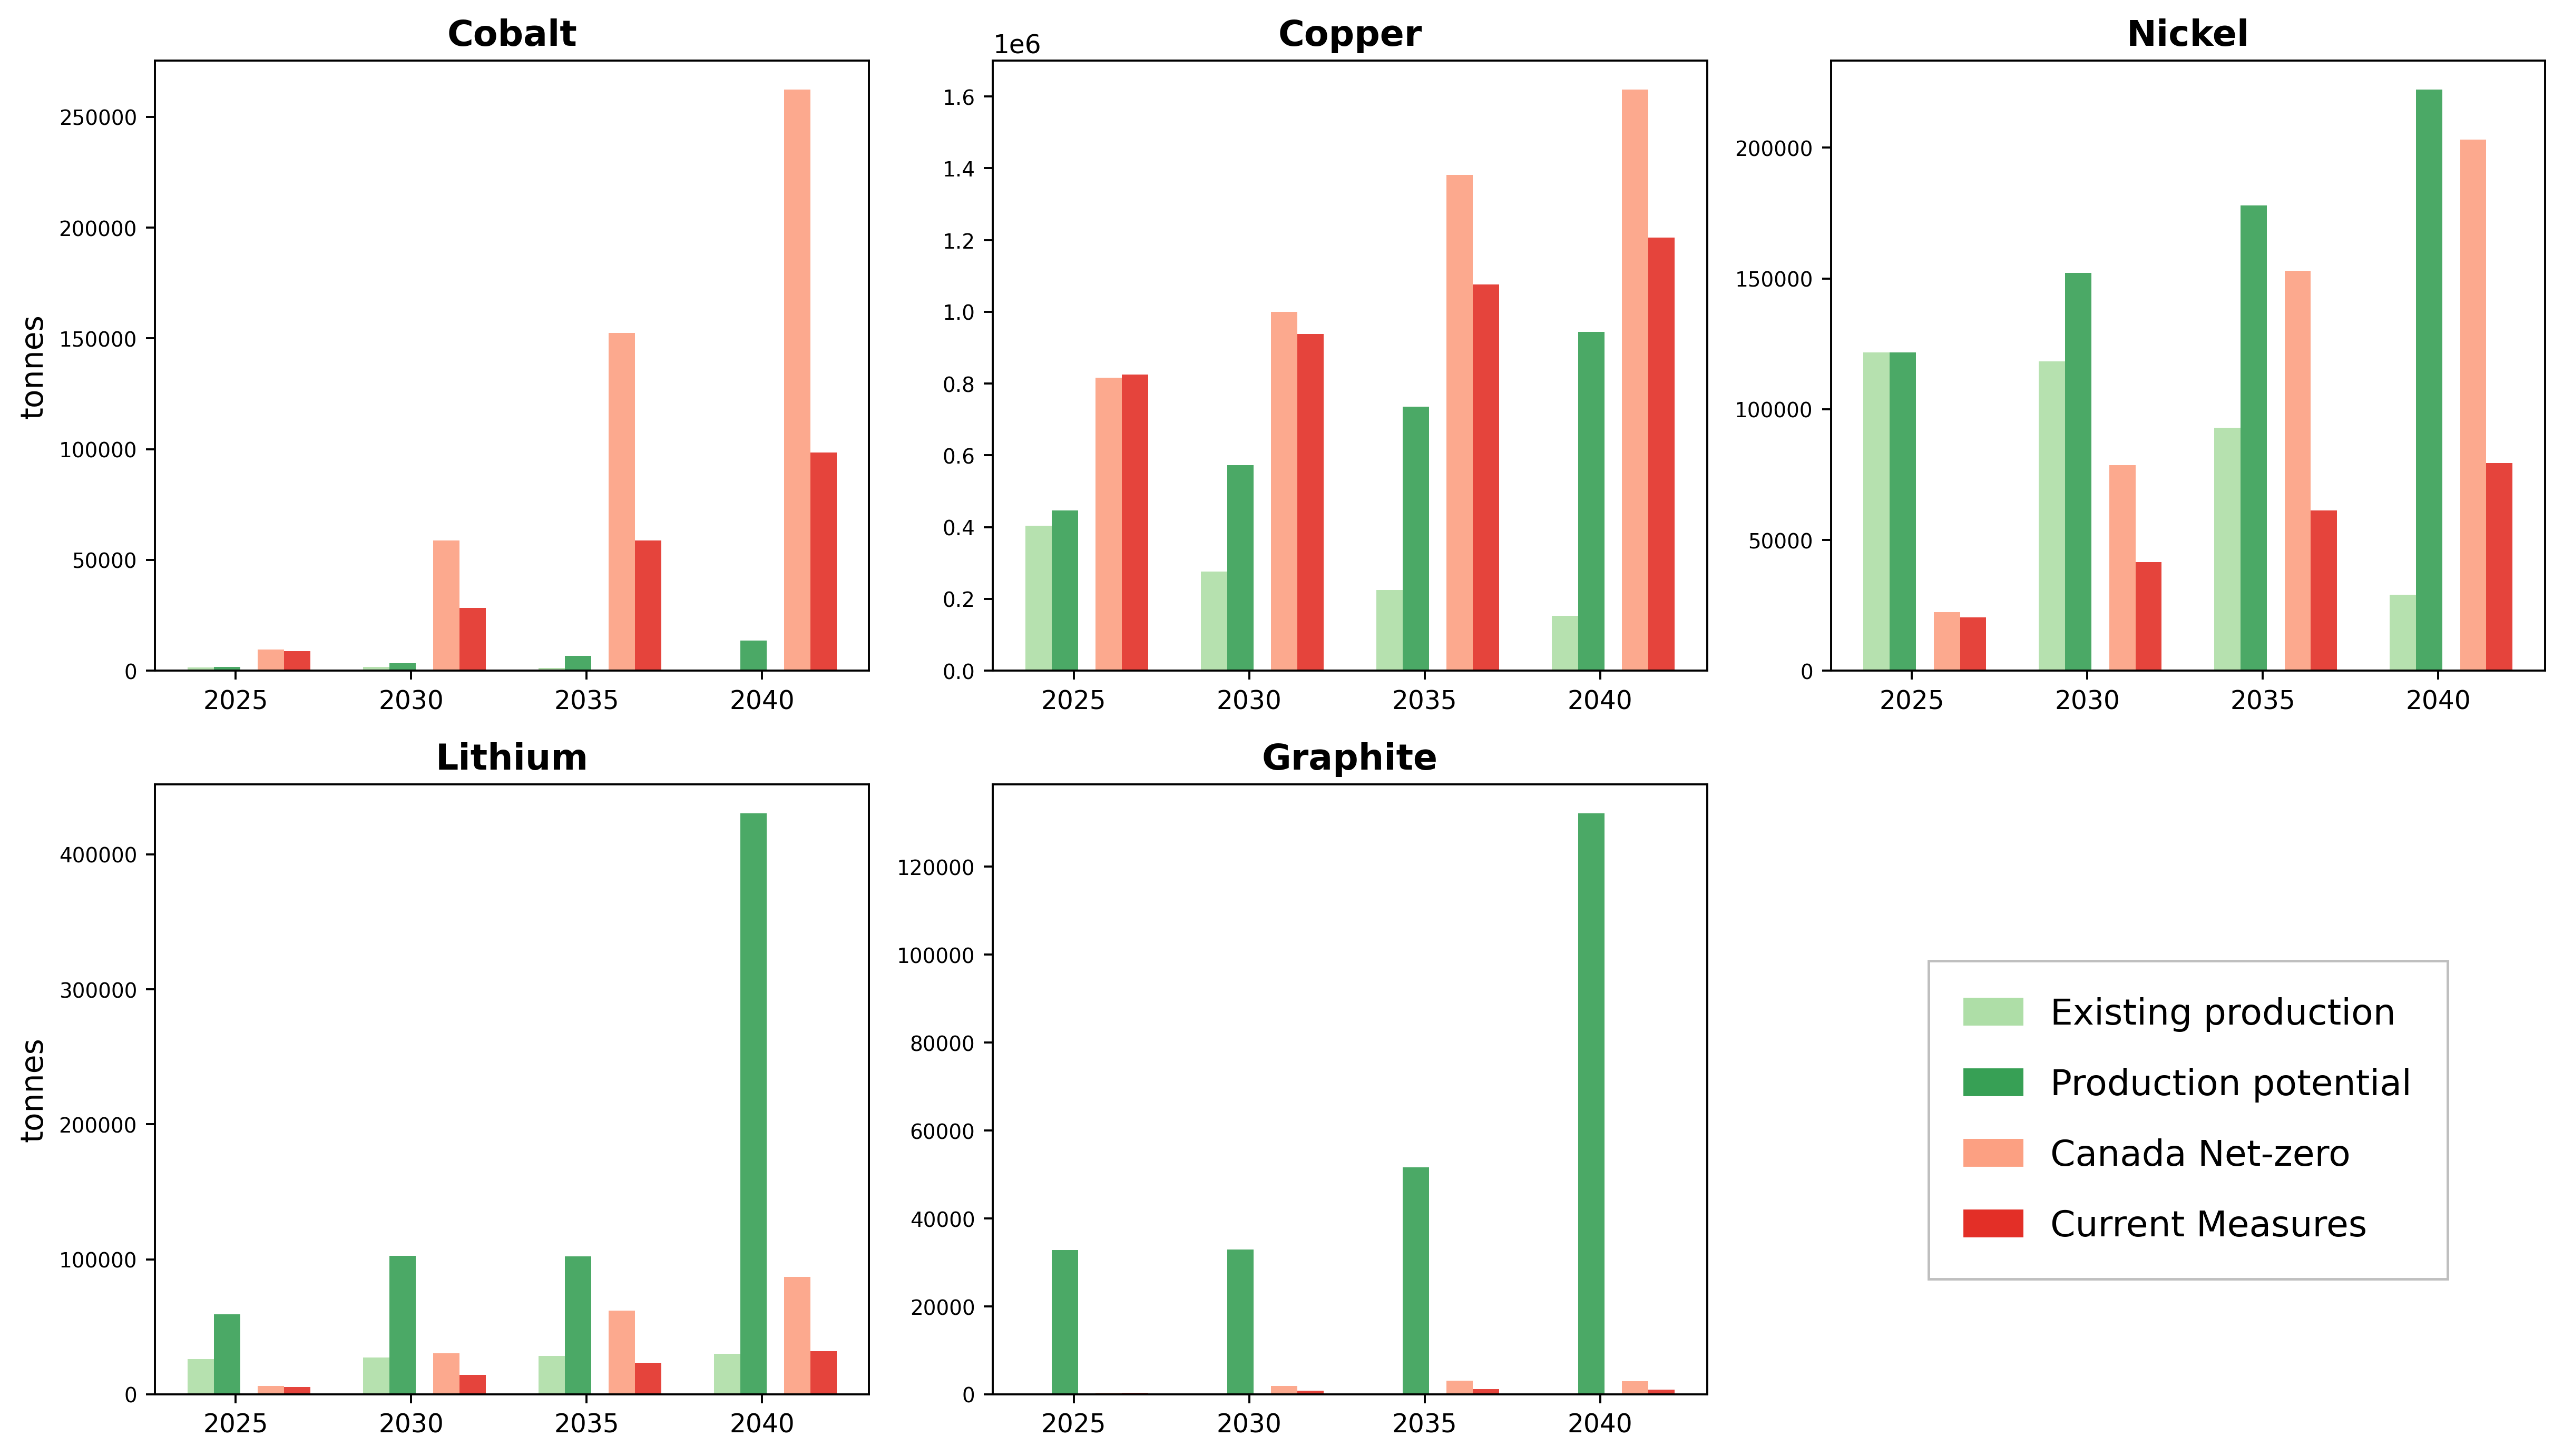

In [51]:
plot_prod_vs_demand_totals_facets_clean(df_prod, df_demand, metals=['Cobalt', 'Copper', 'Nickel', 'Lithium', 'Graphite'], savepath='results/Prod_vs_demand/Prod_vs_demand_selected_metals')